# Weekly Function Tables

Quick table views for all functions after you append the latest weekly results.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

DATA_DIR = Path('data') if Path('data').exists() else Path('CapstoneBO+/data')
csvs = sorted(DATA_DIR.glob('function_*.csv'))
if not csvs:
    raise FileNotFoundError(f'No function CSVs found in {DATA_DIR}')

df_all = pd.concat([pd.read_csv(p) for p in csvs], ignore_index=True)
df_all['function_num'] = df_all['function'].str.extract(r'(\d+)$').astype(int)
df_all = df_all.sort_values(['function_num', 'index']).drop(columns=['function_num'])

print(f'Loaded {len(df_all)} rows from {len(csvs)} functions')


Loaded 271 rows from 8 functions


In [2]:
# Summary table for all functions
summary = (
    df_all.groupby('function')['y0']
    .agg(count='count', min='min', max='max', mean='mean', std='std')
    .sort_index(key=lambda s: s.str.extract(r'(\d+)$').astype(int)[0])
)
f1 = ['function_1'] if 'function_1' in summary.index else []
others = summary.index.difference(f1)

display(
    summary.style
    .format({'max': '{:,.6f}'}, subset=pd.IndexSlice[others, ['max']])  # plain
    .format({'max': '{:.6e}'},  subset=pd.IndexSlice[f1, ['max']])      # scientific
)

,count,min,max,mean,std
function,,,,,
function_1,22,-0.003606,1.648035e-01,0.007326,0.035181
function_2,22,-0.065624,0.651454,0.328766,0.239164
function_3,27,-0.474184,-0.004284,-0.139778,0.148491
function_4,42,-32.625660,0.701305,-12.313153,9.918278
function_5,32,0.112940,"8,662.405001",1606.818249,2550.127537
function_6,32,-3.172478,-0.162953,-1.531130,0.858002
function_7,42,0.002701,3.223213,0.657426,0.943946
function_8,52,5.592193,9.958745,8.222325,1.179578


In [3]:
# Top rows by y0 for each function
TOP_N = 10
for func, sub in df_all.groupby('function', sort=True):
    print(f'\n{func} - top {TOP_N} rows by y0')
    display(sub.sort_values('y0', ascending=False).head(TOP_N))



function_1 - top 10 rows by y0


,function,index,x0,x1,x2,x3,x4,x5,x6,x7,y0
21,function_1,21,0.447536,0.417979,NaN,NaN,NaN,NaN,NaN,NaN,1.648035e-01
20,function_1,20,0.690569,0.707263,NaN,NaN,NaN,NaN,NaN,NaN,1.654037e-07
15,function_1,15,0.298865,0.420432,NaN,NaN,NaN,NaN,NaN,NaN,6.832899e-12
2,function_1,2,0.731024,0.733000,NaN,NaN,NaN,NaN,NaN,NaN,7.710875e-16
7,function_1,7,0.683418,0.861057,NaN,NaN,NaN,NaN,NaN,NaN,2.535001e-40
1,function_1,1,0.574329,0.879898,NaN,NaN,NaN,NaN,NaN,NaN,1.033078e-46
9,function_1,9,0.883890,0.582254,NaN,NaN,NaN,NaN,NaN,NaN,6.229856e-48
10,function_1,10,0.653266,0.206030,NaN,NaN,NaN,NaN,NaN,NaN,1.767330e-70
0,function_1,0,0.319404,0.762959,NaN,NaN,NaN,NaN,NaN,NaN,1.322677e-79
8,function_1,8,0.082507,0.403488,NaN,NaN,NaN,NaN,NaN,NaN,3.606771e-81



function_2 - top 10 rows by y0


,function,index,x0,x1,x2,x3,x4,x5,x6,x7,y0
39,function_2,17,0.716439,0.857645,NaN,NaN,NaN,NaN,NaN,NaN,0.651454
40,function_2,18,0.715356,0.895525,NaN,NaN,NaN,NaN,NaN,NaN,0.624337
31,function_2,9,0.702637,0.926564,NaN,NaN,NaN,NaN,NaN,NaN,0.611205
32,function_2,10,0.729096,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.599608
22,function_2,0,0.665800,0.123969,NaN,NaN,NaN,NaN,NaN,NaN,0.538996
35,function_2,13,0.700386,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.528494
43,function_2,21,0.712205,0.079938,NaN,NaN,NaN,NaN,NaN,NaN,0.501154
41,function_2,19,0.721382,0.881269,NaN,NaN,NaN,NaN,NaN,NaN,0.492189
36,function_2,14,0.716933,0.956736,NaN,NaN,NaN,NaN,NaN,NaN,0.488094
34,function_2,12,0.750544,0.053129,NaN,NaN,NaN,NaN,NaN,NaN,0.424734



function_3 - top 10 rows by y0


...

,function,index,x0,x1,x2,x3,x4,x5,x6,x7,y0
168,function_6,23,0.429103,0.349559,0.583952,0.835409,0.167893,NaN,NaN,NaN,-0.162953
176,function_6,31,0.465348,0.395642,0.588016,0.876307,0.128649,NaN,NaN,NaN,-0.206761
175,function_6,30,0.406691,0.358955,0.544259,0.790415,0.140897,NaN,NaN,NaN,-0.255387
174,function_6,29,0.429780,0.406923,0.730873,0.853184,0.170766,NaN,NaN,NaN,-0.356854
167,function_6,22,0.557384,0.355367,0.540524,0.715106,0.177871,NaN,NaN,NaN,-0.361695
145,function_6,0,0.728186,0.154693,0.732552,0.693997,0.056401,NaN,NaN,NaN,-0.714265
149,function_6,4,0.618812,0.331802,0.187288,0.756238,0.328835,NaN,NaN,NaN,-0.829237
162,function_6,17,0.782880,0.536336,0.443284,0.859700,0.010326,NaN,NaN,NaN,-0.935757
155,function_6,10,0.536797,0.308781,0.411879,0.388225,0.522528,NaN,NaN,NaN,-1.144785
165,function_6,20,0.967526,0.029638,0.848272,0.737615,0.039431,NaN,NaN,NaN,-1.208354



function_7 - top 10 rows by y0


,function,index,x0,x1,x2,x3,x4,x5,x6,x7,y0
216,function_7,39,0.218691,0.218479,0.440618,0.271435,0.335377,0.659655,NaN,NaN,3.223213
217,function_7,40,0.137773,0.151278,0.427151,0.286486,0.291700,0.674164,NaN,NaN,3.217820
218,function_7,41,0.206509,0.061332,0.409412,0.307434,0.302362,0.655302,NaN,NaN,3.173520
210,function_7,33,0.278548,0.346070,0.350542,0.242561,0.342017,0.808355,NaN,NaN,2.244001
214,function_7,37,0.114161,0.018033,0.748271,0.191120,0.296296,0.752669,NaN,NaN,2.069065
209,function_7,32,0.151517,0.432590,0.319463,0.214898,0.378585,0.729619,NaN,NaN,1.999625
212,function_7,35,0.502828,0.346478,0.454090,0.234025,0.292078,0.859981,NaN,NaN,1.585815
183,function_7,6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,NaN,NaN,1.364968
208,function_7,31,0.041997,0.494065,0.252789,0.177536,0.415424,0.704764,NaN,NaN,1.307717
207,function_7,30,0.014990,0.491513,0.234279,0.219709,0.421839,0.744749,NaN,NaN,1.254625



function_8 - top 10 rows by y0


,function,index,x0,x1,x2,x3,x4,x5,x6,x7,y0
268,function_8,49,0.107466,0.115199,0.129783,0.155887,0.772725,0.572681,0.124179,0.123077,9.958745
269,function_8,50,0.061865,0.112818,0.131718,0.105873,0.690058,0.525129,0.064358,0.078369,9.923070
263,function_8,44,0.088044,0.068882,0.169890,0.094910,0.842183,0.540200,0.052510,0.169987,9.920822
266,function_8,47,0.053492,0.010532,0.041476,0.036415,0.855385,0.514374,0.102282,0.748341,9.916773
262,function_8,43,0.181624,0.123000,0.194767,0.000000,0.999999,0.422119,0.210830,0.005616,9.889233
261,function_8,42,0.185401,0.223017,0.201160,0.268389,0.591682,0.511793,0.356781,0.582466,9.879846
264,function_8,45,0.126471,0.243901,0.085430,0.279659,0.979105,0.449387,0.027146,0.983472,9.873947
267,function_8,48,0.046675,0.000000,0.003636,0.032291,0.984044,0.535685,0.039453,0.180790,9.822720
265,function_8,46,0.001264,0.305925,0.066779,0.173216,0.624475,0.310540,0.008286,0.771077,9.815925
270,function_8,51,0.021711,0.000000,0.046566,0.000000,0.744925,0.552628,0.000000,0.000000,9.801572


In [4]:
# Single-function quick look (same style as your snippet)
FUNC = 'function_2'
sub = df_all[df_all['function'] == FUNC].copy()

summary_one = sub['y0'].agg(['count', 'min', 'max', 'mean', 'std'])
display(summary_one)
display(sub.sort_values('y0', ascending=False))


count    21.000000
min      -0.065624
max       0.651454
mean      0.320557
std       0.241873
Name: y0, dtype: float64

,function,index,x0,x1,x2,x3,x4,x5,x6,x7,y0
38,function_2,17,0.716439,0.857645,NaN,NaN,NaN,NaN,NaN,NaN,0.651454
39,function_2,18,0.715356,0.895525,NaN,NaN,NaN,NaN,NaN,NaN,0.624337
30,function_2,9,0.702637,0.926564,NaN,NaN,NaN,NaN,NaN,NaN,0.611205
31,function_2,10,0.729096,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.599608
21,function_2,0,0.665800,0.123969,NaN,NaN,NaN,NaN,NaN,NaN,0.538996
34,function_2,13,0.700386,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.528494
40,function_2,19,0.721382,0.881269,NaN,NaN,NaN,NaN,NaN,NaN,0.492189
35,function_2,14,0.716933,0.956736,NaN,NaN,NaN,NaN,NaN,NaN,0.488094
33,function_2,12,0.750544,0.053129,NaN,NaN,NaN,NaN,NaN,NaN,0.424734
22,function_2,1,0.877791,0.778628,NaN,NaN,NaN,NaN,NaN,NaN,0.420586


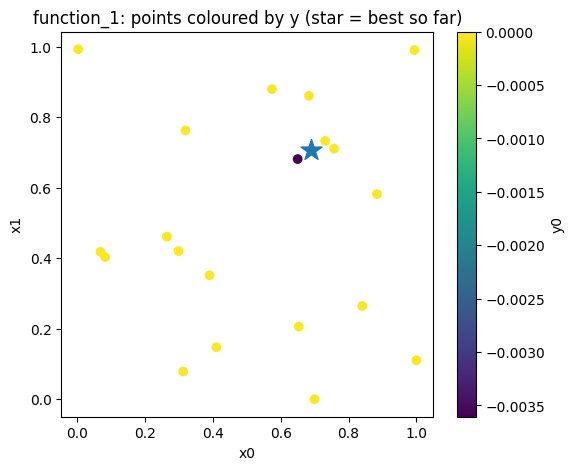

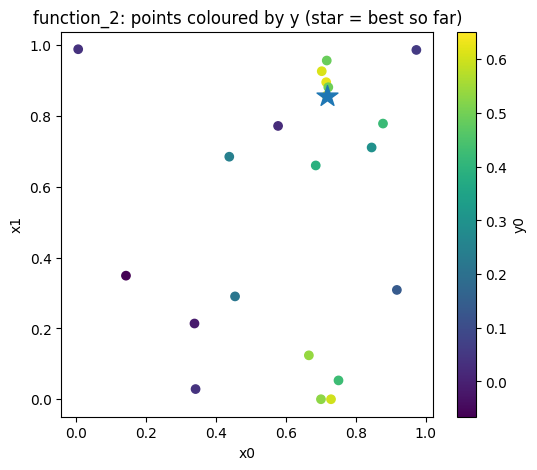

In [5]:
import matplotlib.pyplot as plt

def used_xcols(frame):
    xcols = [c for c in frame.columns if c.startswith("x")]
    # keep only x-columns that actually vary for this function
    return [c for c in xcols if frame[c].nunique(dropna=True) > 1]

def plot_2d(func, data):
    sub = data[data["function"] == func].copy()
    xcols = used_xcols(sub)
    assert len(xcols) == 2, "This is for 2D functions only."

    x0, x1 = xcols
    plt.figure(figsize=(6, 5))
    sc = plt.scatter(sub[x0], sub[x1], c=sub["y0"])
    plt.colorbar(sc, label="y0")
    best = sub.loc[sub["y0"].idxmax()]
    plt.scatter([best[x0]], [best[x1]], marker="*", s=250)
    plt.xlabel(x0); plt.ylabel(x1)
    plt.title(f"{func}: points coloured by y (star = best so far)")
    plt.show()

plot_2d("function_1", df_all)
plot_2d("function_2", df_all)
